# ESPM Course 2025 
## Fifth notebook
Diffusion equation using an implicit scheme but including non linear diffusivity (to reproduce landsliding) and uplift

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import numba

We try to solve the time-dependent diffusion equation:
$$\frac{\partial h}{\partial t}=\frac{\partial}{\partial x}K_d\frac{\partial h}{\partial x}+U$$
where
$$K_d=\frac{K_{d,0}}{1-(S/S_0)^2}$$
with the following initial condition:
$$h(t=0)=0$$
and boundary conditions:
$$h(x=0;x=L)=0$$
using a centered-difference, implicit finite difference scheme:
$$h_i(t+\Delta t)=h_i(t)+\frac{\Delta t}{\Delta x^2}(K_{d,i}h_{i+1}(t+\Delta t)-(K_{d,i}+K_{d,i-1})h_i(t+\Delta t)+K_{d,i-1}h_{i-1}(t+\Delta t))+U\Delta t$$
where the diffusivities, $K_{d_i}$ are sampled in between two grid points ($i$ and $i+1$)

This leads to the solution of a system of algebraic equations that has a tridiagonal form:
$$Ah=b$$
The diagonal term is given by:
$$A_{i,i}=1+2\frac{K_d\Delta t}{\Delta x^2}$$
and the off-diagonal terms are given by:
$$A_{i,i-1}=A_{i+1,i}=-\frac{K_d\Delta t}{\Delta x^2}$$
The rhs term, $b$, is made of:
$$b=h(t) + U\Delta t$$
To solve such a system, we use a tridiagonal matrix solver derived from Numerical Recipes.

In [4]:
@numba.njit
def tridag(a, b, c, r):
    """
    Function to solve a tri-diagonal system of equations
    a is lower diagonal, b is diagonal, c is upper diagonal, r is rhigh hand side
    tridag returns an array of size n containing the solution to the system of equations
    """

    n = len(r)
    res = np.empty(n)
    gam = np.empty(n)

    if b[0] == 0:
        raise RuntimeError("diagonal contains nil element in tridag")

    bet = b[0]
    res[0] = r[0] / bet
    for j in range(1, n):  # in Fortran the range is 2,n
        gam[j] = c[j - 1] / bet
        bet = b[j] - a[j] * gam[j]
        if bet == 0:
            raise RuntimeError("diagonal contains nil element in tridag")
        res[j] = (r[j] - a[j] * res[j - 1]) / bet

    for j in range(n - 2, -1, -1):  # in Fortran the range is n-1,1,-1
        res[j] = res[j] - gam[j + 1] * res[j + 1]

    return res

In [5]:
xl = 1000 # (m)
nx = 101
x = np.linspace(0, xl, nx)
dx = xl/(nx - 1)
Kd0 = 1e-1
S0 = np.tan(30/180*np.pi)
U = 1e-4
tau = xl**2/Kd0
dt = tau/1e4
nstep = 10000

courant = dt*Kd0/dx**2
print(tau,dt,courant)

10000000.0 1000.0 1.0


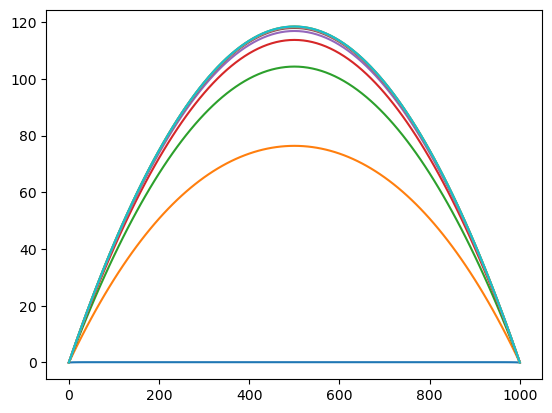

In [6]:
h = np.zeros_like(x)

uplift = U*dt*np.ones_like(x)
uplift[0] = 0
uplift[-1] = 0

for step in range(nstep):
    
    S = (h[1:] - h[:-1])/dx
    Kd = Kd0/(1 + (S/S0)**2)
    diag = 1 + dt/dx**2*(Kd[1:] + Kd[:-1])
    sup = -dt/dx**2*Kd
    sub = -dt/dx**2*Kd
    diag = np.concatenate(([1],diag,[1]))
    sup = np.concatenate(([0],sup))
    sub = np.concatenate((sub,[0]))

    h = tridag(sub, diag, sup, h + uplift)
    if step%(nstep/10)==0:
        plt.plot(x, h, label=f'step {step}')


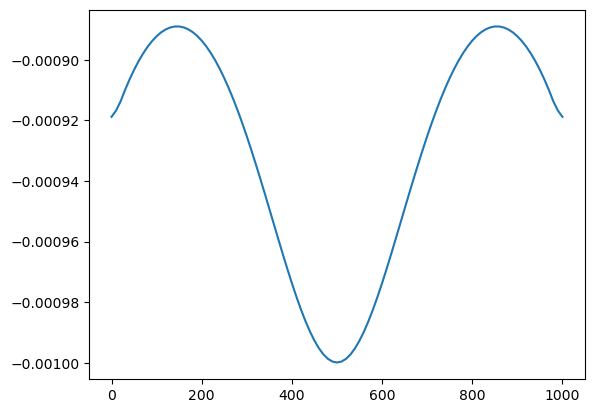

In [7]:
plt.plot(x,np.gradient(np.gradient(h,dx,edge_order=2),dx,edge_order=2));